# Unit06 範例演練 02 — 蒸餾塔組之成分分析

本 Notebook 以多塔串聯蒸餾系統為例，示範如何建立各塔之整體物料平衡方程組，將其表達為線性聯立方程組 $\mathbf{Ax}=\mathbf{b}$ ，
並使用 `scipy.linalg.solve()` 求解各出口流率與組成分布。

## 學習目標
- 由蒸餾塔組之整體物料平衡建立矩陣方程式 $\mathbf{Ax}=\mathbf{b}$
- 使用 `np.linalg.matrix_rank()` 判定解的存在性與唯一性
- 使用 `scipy.linalg.solve()` 求解唯一解系統
- 利用求解流率計算各塔出口組成分布
- 進行殘差驗證、質量守恆與組成合理性檢查
- 以視覺化方式呈現各股流的流率與組成結果

**參考來源**：Cutlip & Shacham (1999)

---
### 0. 環境設定

In [9]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit06_Example_02'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit06'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit06
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_02
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_02\figs


---
### 1. 載入套件

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy import linalg

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy  版本: {np.__version__}")
import scipy
print(f"  scipy  版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy  版本: 1.23.5
  scipy  版本: 1.15.2
  matplotlib 版本: 3.10.8


---
## 2. 問題描述

### 蒸餾塔組之成分分析

某工廠利用以下的蒸餾塔組，分離**對二甲苯 (para-xylene)**、**苯乙烯 (styrene)**、**甲苯 (toluene)** 及**苯 (benzene)** 等四成分（Cutlip & Shacham, 1999）。

**系統架構**：進料流 F 首先進入第一個蒸餾塔，塔頂出口為 $D_1$ ，塔底出口為 $B_1$ 。 $D_1$ 再進入第二個蒸餾塔（塔頂 $D_2$ 、塔底 $B_2$ ）， $B_1$ 再進入第三個蒸餾塔（塔頂 $D_3$ 、塔底 $B_3$ ）。

**已知條件**：
- 進料流率 $F = 70\ \text{mol/hr}$
- 進料組成（莫耳分率）：para-xylene = 0.15，styrene = 0.25，toluene = 0.40，benzene = 0.20
- 各出口股流組成（莫耳分率）如下表：

| 成分 | $D_2$ | $B_2$ | $D_3$ | $B_3$ |
|:----:|:-----:|:-----:|:-----:|:-----:|
| para-xylene  | 0.07 | 0.18 | 0.15 | 0.24 |
| styrene      | 0.04 | 0.24 | 0.10 | 0.65 |
| toluene      | 0.54 | 0.42 | 0.54 | 0.10 |
| benzene      | 0.35 | 0.16 | 0.21 | 0.01 |

**問題**：
- **(a)** 計算 $D_2$ 、 $B_2$ 、 $D_3$ 、 $B_3$ 之流率 (mol/hr)
- **(b)** 計算第一塔塔頂 $D_1$ 及塔底 $B_1$ 處各成分的莫耳分率

---

### 數學模型

**(a) 建立物料平衡方程組：**

對各成分進行整體物料平衡（進料 = 各出口流之總和）：

$$
a_{j,D_2} \cdot D_2 + a_{j,B_2} \cdot B_2 + a_{j,D_3} \cdot D_3 + a_{j,B_3} \cdot B_3 = z_j \cdot F, \quad j = 1,2,3,4
$$

其中 $a_{j,k}$ 為出口股 $k$ 中成分 $j$ 之莫耳分率， $z_j$ 為進料中成分 $j$ 之莫耳分率。

寫成矩陣形式 $\mathbf{Ax} = \mathbf{b}$ ：

$$
\underbrace{\begin{bmatrix}
0.07 & 0.18 & 0.15 & 0.24 \\
0.04 & 0.24 & 0.10 & 0.65 \\
0.54 & 0.42 & 0.54 & 0.10 \\
0.35 & 0.16 & 0.21 & 0.01
\end{bmatrix}}_{\mathbf{A}}
\underbrace{\begin{bmatrix}D_2\\B_2\\D_3\\B_3\end{bmatrix}}_{\mathbf{x}}
=
\underbrace{\begin{bmatrix}0.15\\0.25\\0.40\\0.20\end{bmatrix}}_{\mathbf{z}} \times 70
=
\underbrace{\begin{bmatrix}10.5\\17.5\\28.0\\14.0\end{bmatrix}}_{\mathbf{b}}
$$

**(b) 計算第一塔出口組成：**

$$
D_1 = D_2 + B_2, \quad
\begin{bmatrix}x_1\\x_2\\x_3\\x_4\end{bmatrix}_{D_1}
= \frac{1}{D_1}
\begin{bmatrix}0.07 & 0.18\\0.04 & 0.24\\0.54 & 0.42\\0.35 & 0.16\end{bmatrix}
\begin{bmatrix}D_2\\B_2\end{bmatrix}
$$

$$
B_1 = D_3 + B_3, \quad
\begin{bmatrix}\tilde{x}_1\\\tilde{x}_2\\\tilde{x}_3\\\tilde{x}_4\end{bmatrix}_{B_1}
= \frac{1}{B_1}
\begin{bmatrix}0.15 & 0.24\\0.10 & 0.65\\0.54 & 0.10\\0.21 & 0.01\end{bmatrix}
\begin{bmatrix}D_3\\B_3\end{bmatrix}
$$

---
## 3. Step 1 — 建構係數矩陣與右端向量

In [11]:
# ============================================================
# Step 1: 建構係數矩陣 A 與右端向量 b
# ============================================================
# 各出口股流之成分莫耳分率（列=成分，行=出口股流 D2/B2/D3/B3）
A = np.array([
    [0.07, 0.18, 0.15, 0.24],   # para-xylene
    [0.04, 0.24, 0.10, 0.65],   # styrene
    [0.54, 0.42, 0.54, 0.10],   # toluene
    [0.35, 0.16, 0.21, 0.01],   # benzene
], dtype=float)

# 進料條件
comp_names = ['para-xylene', 'styrene', 'toluene', 'benzene']
F     = 70.0                                              # mol/hr
z     = np.array([0.15, 0.25, 0.40, 0.20], dtype=float)  # 進料莫耳分率
b     = z * F                                             # 右端向量 (mol/hr)

print("係數矩陣 A（各出口股流莫耳分率）：")
header = f"{'成分':<14}{'D2':>8}{'B2':>8}{'D3':>8}{'B3':>8}"
print(header)
print("-" * len(header))
for i, name in enumerate(comp_names):
    print(f"  {name:<12}  {A[i,0]:>6.2f}  {A[i,1]:>6.2f}  {A[i,2]:>6.2f}  {A[i,3]:>6.2f}")
print(f"\n進料流率 F = {F:.1f} mol/hr")
print(f"進料組成 z = {z}")
print(f"右端向量 b = z × F = {b}")
print(f"\n矩陣形狀: A = {A.shape}, b = {b.shape}")

係數矩陣 A（各出口股流莫耳分率）：
成分                  D2      B2      D3      B3
----------------------------------------------
  para-xylene     0.07    0.18    0.15    0.24
  styrene         0.04    0.24    0.10    0.65
  toluene         0.54    0.42    0.54    0.10
  benzene         0.35    0.16    0.21    0.01

進料流率 F = 70.0 mol/hr
進料組成 z = [0.15 0.25 0.4  0.2 ]
右端向量 b = z × F = [10.5 17.5 28.  14. ]

矩陣形狀: A = (4, 4), b = (4,)


---
## 4. Step 2 — 秩判定：確認解的存在性與唯一性

使用 Rouché–Capelli 定理判定：

| 條件 | 結論 |
|------|------|
| $\operatorname{rank}(\mathbf{A}) < \operatorname{rank}([\mathbf{A}\mid\mathbf{b}])$ | 無解 |
| $\operatorname{rank}(\mathbf{A}) = \operatorname{rank}([\mathbf{A}\mid\mathbf{b}]) = n$ | **唯一解** |
| $\operatorname{rank}(\mathbf{A}) = \operatorname{rank}([\mathbf{A}\mid\mathbf{b}]) < n$ | 無窮多解 |

In [12]:
# ============================================================
# Step 2: 秩判定
# ============================================================
m, n    = A.shape
rank_A  = np.linalg.matrix_rank(A)
rank_Ab = np.linalg.matrix_rank(np.column_stack([A, b]))

print("=" * 45)
print(f"矩陣維度: {m} 個方程式, {n} 個未知數")
print(f"rank(A)       = {rank_A}")
print(f"rank([A | b]) = {rank_Ab}")
print(f"n             = {n}")
print("-" * 45)

if rank_A < rank_Ab:
    print("→ 無解（方程式互相矛盾）")
elif rank_A == rank_Ab == n:
    print("→ 唯一解 ✓  (rank(A) = rank([A|b]) = n)")
    print("  可使用 scipy.linalg.solve() 求解")
else:
    free = n - rank_A
    print(f"→ 無窮多解（自由度 = {free}）")
    print("  建議使用 scipy.linalg.pinv() 求最小範數解")

det_A = np.linalg.det(A)
print(f"\ndet(A) = {det_A:.6f}")
print(f"  det(A) ≠ 0 → 係數矩陣可逆，唯一解存在 ✓" if abs(det_A) > 1e-10 else "  det(A) ≈ 0 → 奇異矩陣！")
print("=" * 45)

矩陣維度: 4 個方程式, 4 個未知數
rank(A)       = 4
rank([A | b]) = 4
n             = 4
---------------------------------------------
→ 唯一解 ✓  (rank(A) = rank([A|b]) = n)
  可使用 scipy.linalg.solve() 求解

det(A) = 0.000496
  det(A) ≠ 0 → 係數矩陣可逆，唯一解存在 ✓


---
## 5. Step 3 — `scipy.linalg.solve()` 求解各出口流率

In [13]:
# ============================================================
# Step 3: 使用 scipy.linalg.solve() 求唯一解
# ============================================================
x = linalg.solve(A, b)   # x = [D2, B2, D3, B3]
D2, B2, D3, B3 = x

stream_names = ['D2', 'B2', 'D3', 'B3']
print("各出口股流流率 (mol/hr):")
print("-" * 35)
for name, val in zip(stream_names, x):
    print(f"  {name}: {val:9.4f} mol/hr")
print("-" * 35)
print(f"  合計: {x.sum():9.4f} mol/hr  (進料 F = {F:.1f} mol/hr)")

各出口股流流率 (mol/hr):
-----------------------------------
  D2:   26.2500 mol/hr
  B2:   17.5000 mol/hr
  D3:    8.7500 mol/hr
  B3:   17.5000 mol/hr
-----------------------------------
  合計:   70.0000 mol/hr  (進料 F = 70.0 mol/hr)


---
## 6. Step 4 — 解的驗證

驗證包含三項：
1. **數值殘差**：計算 $\|\mathbf{Ax} - \mathbf{b}\|_2$ ，應為機器精度（ $\lesssim 10^{-12}$ ）
2. **物理合理性**：各出口流率應 $> 0$ （不能為負值）
3. **質量守恆**：各成分計算結果之組成應與進料平衡一致；出口流率總和應等於進料流率 70 mol/hr

In [14]:
# ============================================================
# Step 4: 解的驗證
# ============================================================
print("=" * 55)
print("驗證 1 — 數值殘差")
print("-" * 55)
residual     = np.linalg.norm(A @ x - b)
rel_residual = residual / (np.linalg.norm(A) * np.linalg.norm(x))
cond_A       = np.linalg.cond(A)
print(f"  絕對殘差 ||Ax - b||     = {residual:.4e}")
print(f"  相對殘差               = {rel_residual:.4e}")
print(f"  矩陣條件數 κ(A)        = {cond_A:.4f}")
status = "✓ 良態系統，求解精確" if cond_A < 1e6 else "⚠ 條件數偏大"
print(f"  → {status}")

print("\n驗證 2 — 物理合理性（各出口流率 > 0）")
print("-" * 55)
all_positive = True
for name, val in zip(stream_names, x):
    flag = "✓" if val > 0 else "✗ 負值!"
    print(f"  {name} = {val:.4f} mol/hr  {flag}")
    if val <= 0:
        all_positive = False
print(f"  → {'✓ 所有出口流率均為正值，物理上合理' if all_positive else '⚠ 存在負值，請重新確認問題設定'}")

print("\n驗證 3 — 質量守恆")
print("-" * 55)
total_out = x.sum()
print(f"  出口總流率 = {total_out:.4f} mol/hr  (進料 F = {F:.1f} mol/hr)  "
      + ("✓" if abs(total_out - F) < 1e-8 else "⚠"))
print()
calc_b   = A @ x                  # 各成分計算結果 (mol/hr)
calc_z   = calc_b / F             # 各成分計算莫耳分率
print(f"  {'成分':<14} | {'計算(mol/hr)':>12} | {'計算組成':>10} | {'進料組成':>10} | 匹配")
print(f"  {'-'*14}-+-{'-'*12}-+-{'-'*10}-+-{'-'*10}-+------")
for j, name in enumerate(comp_names):
    match = "✓" if abs(calc_z[j] - z[j]) < 1e-8 else f"⚠ Δ={calc_z[j]-z[j]:+.6f}"
    print(f"  {name:<14} | {calc_b[j]:>12.4f} | {calc_z[j]:>10.4f} | {z[j]:>10.4f} | {match}")
print("=" * 55)

驗證 1 — 數值殘差
-------------------------------------------------------
  絕對殘差 ||Ax - b||     = 3.9721e-15
  相對殘差               = 8.5366e-17
  矩陣條件數 κ(A)        = 154.2979
  → ✓ 良態系統，求解精確

驗證 2 — 物理合理性（各出口流率 > 0）
-------------------------------------------------------
  D2 = 26.2500 mol/hr  ✓
  B2 = 17.5000 mol/hr  ✓
  D3 = 8.7500 mol/hr  ✓
  B3 = 17.5000 mol/hr  ✓
  → ✓ 所有出口流率均為正值，物理上合理

驗證 3 — 質量守恆
-------------------------------------------------------
  出口總流率 = 70.0000 mol/hr  (進料 F = 70.0 mol/hr)  ✓

  成分             |   計算(mol/hr) |       計算組成 |       進料組成 | 匹配
  ---------------+--------------+------------+------------+------
  para-xylene    |      10.5000 |     0.1500 |     0.1500 | ✓
  styrene        |      17.5000 |     0.2500 |     0.2500 | ✓
  toluene        |      28.0000 |     0.4000 |     0.4000 | ✓
  benzene        |      14.0000 |     0.2000 |     0.2000 | ✓


---
## 7. Part (b) — 計算第一塔出口組成

已知 $D_2$ 、 $B_2$ 、 $D_3$ 、 $B_3$ 後，利用第二塔與第三塔之成分物料平衡求出 $D_1$ 、 $B_1$ 的各成分莫耳分率：

- $D_1 = D_2 + B_2$ （第二塔進料 = 第一塔塔頂）
- $B_1 = D_3 + B_3$ （第三塔進料 = 第一塔塔底）

In [15]:
# ============================================================
# Part (b): 計算 D1、B1 之各成分莫耳分率
# ============================================================

# 第二塔之組成係數（成分 × 股流 [D2, B2]）
A_col2 = np.array([
    [0.07, 0.18],   # para-xylene
    [0.04, 0.24],   # styrene
    [0.54, 0.42],   # toluene
    [0.35, 0.16],   # benzene
], dtype=float)

# 第三塔之組成係數（成分 × 股流 [D3, B3]）
A_col3 = np.array([
    [0.15, 0.24],   # para-xylene
    [0.10, 0.65],   # styrene
    [0.54, 0.10],   # toluene
    [0.21, 0.01],   # benzene
], dtype=float)

# D1、B1 流率
D1 = D2 + B2   # mol/hr
B1 = D3 + B3   # mol/hr

# D1、B1 各成分莫耳分率
x_D1 = (A_col2 @ np.array([D2, B2])) / D1   # D1 組成
x_B1 = (A_col3 @ np.array([D3, B3])) / B1   # B1 組成

print("第一塔出口流率：")
print(f"  D1 (塔頂) = {D1:.4f} mol/hr  (= D2 + B2)")
print(f"  B1 (塔底) = {B1:.4f} mol/hr  (= D3 + B3)")
print(f"  驗證: D1 + B1 = {D1+B1:.4f} mol/hr  (= F = {F:.1f} mol/hr)  "
      + ("✓" if abs(D1 + B1 - F) < 1e-8 else "⚠"))

print("\n第一塔各出口組成（莫耳分率）：")
print(f"  {'成分':<14} | {'D1 (塔頂)':>10} | {'B1 (塔底)':>10}")
print(f"  {'-'*14}-+-{'-'*10}-+-{'-'*10}")
for j, name in enumerate(comp_names):
    print(f"  {name:<14} | {x_D1[j]:>10.4f} | {x_B1[j]:>10.4f}")
print(f"\n  組成總和驗證:")
print(f"  sum(x_D1) = {x_D1.sum():.6f}  {'✓' if abs(x_D1.sum()-1)<1e-8 else '⚠'}")
print(f"  sum(x_B1) = {x_B1.sum():.6f}  {'✓' if abs(x_B1.sum()-1)<1e-8 else '⚠'}")

第一塔出口流率：
  D1 (塔頂) = 43.7500 mol/hr  (= D2 + B2)
  B1 (塔底) = 26.2500 mol/hr  (= D3 + B3)
  驗證: D1 + B1 = 70.0000 mol/hr  (= F = 70.0 mol/hr)  ✓

第一塔各出口組成（莫耳分率）：
  成分             |    D1 (塔頂) |    B1 (塔底)
  ---------------+------------+-----------
  para-xylene    |     0.1140 |     0.2100
  styrene        |     0.1200 |     0.4667
  toluene        |     0.4920 |     0.2467
  benzene        |     0.2740 |     0.0767

  組成總和驗證:
  sum(x_D1) = 1.000000  ✓
  sum(x_B1) = 1.000000  ✓


---
## 8. 結果視覺化

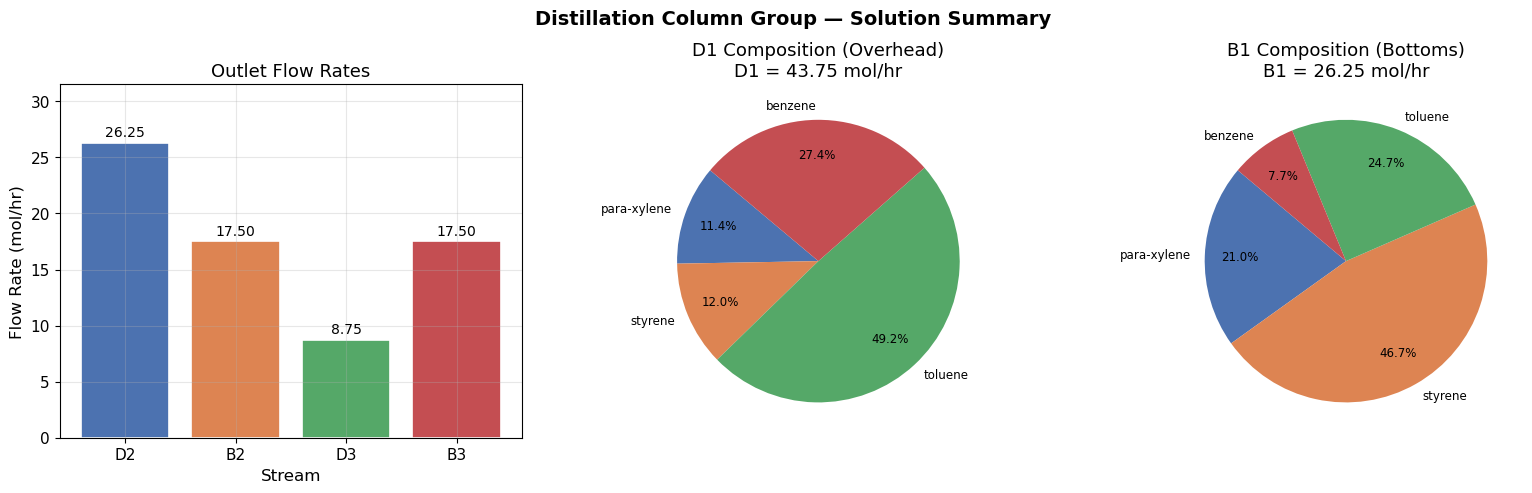

✓ 圖檔已儲存至: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_02\figs\distillation_solution.png


In [16]:
# ============================================================
# 結果視覺化
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distillation Column Group — Solution Summary', fontsize=14, fontweight='bold')

colors_streams = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
comp_labels    = ['para-xylene', 'styrene', 'toluene', 'benzene']

# ─── 子圖 1：各出口股流流率長條圖 ───
ax = axes[0]
bars = ax.bar(stream_names, x, color=colors_streams, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, x):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{v:.2f}', ha='center', va='bottom', fontsize=10)
ax.set_title('Outlet Flow Rates')
ax.set_xlabel('Stream')
ax.set_ylabel('Flow Rate (mol/hr)')
ax.set_ylim(0, max(x) * 1.20)

# ─── 子圖 2：D1（塔頂）組成 ───
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    x_D1, labels=comp_labels, autopct='%1.1f%%',
    colors=colors_streams, startangle=140, pctdistance=0.75,
    textprops={'fontsize': 8.5}
)
ax.set_title(f'D1 Composition (Overhead)\nD1 = {D1:.2f} mol/hr')

# ─── 子圖 3：B1（塔底）組成 ───
ax = axes[2]
wedges, texts, autotexts = ax.pie(
    x_B1, labels=comp_labels, autopct='%1.1f%%',
    colors=colors_streams, startangle=140, pctdistance=0.75,
    textprops={'fontsize': 8.5}
)
ax.set_title(f'B1 Composition (Bottoms)\nB1 = {B1:.2f} mol/hr')

plt.tight_layout()
fig_path = FIG_DIR / 'distillation_solution.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存至: {fig_path}")